In [1]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt

from data import generate_examples
from model import DyckTransformer

In [2]:
det_train_data = generate_examples(50000, task="detection")
det_dev_data = generate_examples(5000, task="detection")
det_test_data = generate_examples(5000, task="detection")
det_ood_test_datata = generate_examples(5000, min_len=40, max_len=80, max_depth=7, task="detection")

In [3]:
VOCAB = ["(", ")", "[", "]", "[PAD]", "[CLS]", "[SEP]"]
stoi = {tok: i for i, tok in enumerate(VOCAB)}
itos = {i: tok for tok, i in stoi.items()}

In [4]:
edit_label_vocab = ["OK", "DELETE", "INSERT())", "INSERT(])", "REPLACE())", "REPLACE(])"]
edit_stoi = {l: i for i, l in enumerate(edit_label_vocab)}

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
model = DyckTransformer(
    vocab_size=len(VOCAB),
    pad_idx=stoi["[PAD]"],
    num_edit_labels=6,
    d_model=32,       # was 128
    n_heads=2,        # was 4
    n_layers=1,       # was 2
    max_len=80,
    dropout=0.0
)
torch.nn.init.zeros_(model.cls_head.bias)
torch.nn.init.xavier_uniform_(model.cls_head.weight)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [7]:
tiny_data = det_train_data[:5000]


In [8]:

for tokens, label in tiny_data[:5]:
    print(label, tokens[:10])

1 ['[CLS]', '[', ']', '(', '(', ')', '(', '(', '[', ']']
0 ['[CLS]', '[', '(', ')', '(', '(', '[', ']', '(', ')']
0 ['[CLS]', '(', '(', ')', '(', ')', '[', '(', '(', ')']
1 ['[CLS]', '(', '[', '(', '(', ')', ')', '(', '[', ']']
1 ['[CLS]', '[', '[', '(', '(', ')', '(', ')', ')', ']']


In [9]:

model.eval()
with torch.no_grad():
    batch = tiny_data[:32]
    xs, ys = zip(*batch)
    xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
    ys = torch.tensor(ys).to(device)
    cls_logits, _ = model(xs)
    preds = torch.argmax(cls_logits, dim=1)
    print("predictions:", preds.tolist())
    print("labels:     ", ys.tolist())

predictions: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
labels:      [1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1]


c:\Users\sarav\projects\dyck_transformer\.pixi\envs\default\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\bld\libtorch_1772176602146\work\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


In [10]:
loss_fn = nn.CrossEntropyLoss()

batch_size = 64
train_loss_curve = []

def accuracy(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

for epoch in range(10):
    model.train()
    total_loss = 0
    total_acc = 0

    for i in range(0, len(tiny_data), batch_size):
        batch = tiny_data[i:i+batch_size]
        xs, ys = zip(*batch)
        xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
        ys = torch.tensor(ys).to(device)
        cls_logits, _ = model(xs)
        loss = loss_fn(cls_logits, ys)
        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        total_acc += accuracy(cls_logits, ys)

    avg_loss = total_loss / (len(tiny_data) / batch_size)
    avg_acc = total_acc / (len(tiny_data) / batch_size)

    train_loss_curve.append(avg_loss)

    print("epoch", epoch, "loss", avg_loss, "train acc", avg_acc)

    model.eval()
    dev_acc = 0

    with torch.no_grad():
        for i in range(0, len(det_dev_data), batch_size):
            batch = det_dev_data[i:i+batch_size]

            xs, ys = zip(*batch)

            xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
            ys = torch.tensor(ys).to(device)

            cls_logits, _ = model(xs)
            dev_acc += accuracy(cls_logits, ys)

    dev_acc /= (len(det_dev_data) / batch_size)
    print("dev acc:", dev_acc)

    model.eval()
    tiny_acc = 0
    with torch.no_grad():
        for i in range(0, len(tiny_data), batch_size):
            batch = tiny_data[i:i+batch_size]
            xs, ys = zip(*batch)
            xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
            ys = torch.tensor(ys).to(device)
            cls_logits, _ = model(xs)
            tiny_acc += accuracy(cls_logits, ys)
    tiny_acc /= (len(tiny_data) / batch_size)
    print("tiny train acc (eval mode):", tiny_acc)

epoch 0 loss 0.723110018157959 train acc 0.4994
dev acc: 0.5224
tiny train acc (eval mode): 0.5362
epoch 1 loss 0.7054416763305664 train acc 0.5046
dev acc: 0.5244
tiny train acc (eval mode): 0.5202
epoch 2 loss 0.7042177207946777 train acc 0.5096
dev acc: 0.5266
tiny train acc (eval mode): 0.516
epoch 3 loss 0.703672486114502 train acc 0.516
dev acc: 0.5244
tiny train acc (eval mode): 0.5144
epoch 4 loss 0.7030708084106445 train acc 0.5184
dev acc: 0.531
tiny train acc (eval mode): 0.5236
epoch 5 loss 0.7027309730529785 train acc 0.52
dev acc: 0.5206
tiny train acc (eval mode): 0.51
epoch 6 loss 0.7024344802856445 train acc 0.5174
dev acc: 0.521
tiny train acc (eval mode): 0.5096
epoch 7 loss 0.7019909454345703 train acc 0.517
dev acc: 0.5202
tiny train acc (eval mode): 0.5078
epoch 8 loss 0.7014259475708008 train acc 0.5204
dev acc: 0.518
tiny train acc (eval mode): 0.51
epoch 9 loss 0.7007458686828614 train acc 0.5226
dev acc: 0.522
tiny train acc (eval mode): 0.5138


In [11]:
# After a few epochs, check what the model actually predicts on dev
model.eval()
all_preds = []
with torch.no_grad():
    for i in range(0, 100, 50):  # just first 100 dev examples
        batch = det_dev_data[i:i+50]
        xs, ys = zip(*batch)
        xs = torch.tensor([[stoi[t] for t in x] for x in xs]).to(device)
        cls_logits, _ = model(xs)
        preds = torch.argmax(cls_logits, dim=1)
        all_preds.extend(preds.tolist())

print(set(all_preds))  # if this prints {0} or {1}, model is collapsed

{0, 1}


In [12]:
torch.save(model.state_dict(), "../models/det_dyck_transformer.pt")

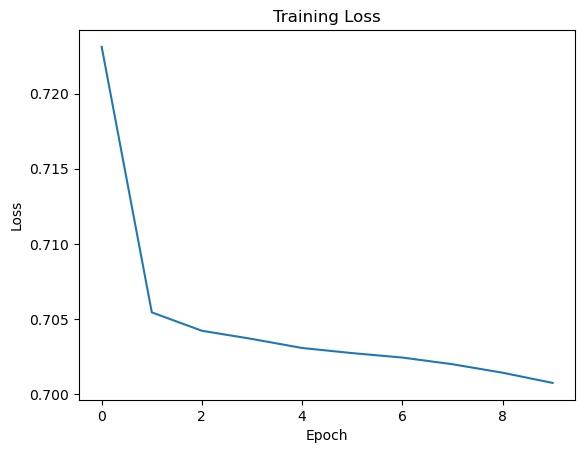

In [13]:
plt.plot(train_loss_curve)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()